# 02 — Missingness and Encoding

Two of the defects listed in `PLAN.md` are settled here, both of them silent: each
produces a number that looks entirely reasonable while being built on an unchecked
assumption.

**D6 — missingness assumed to be random.** The reference median-imputes `credit_score`
and `annual_mileage` without testing whether the *absence* of a value is itself
predictive. If it were, imputing would destroy information.

**D3 — imputation leakage.** The reference computes those medians over all 10,000 rows,
including rows that later become the test set.

A third, D4, is fixed in code rather than analysis: encoding is driven by an explicit
feature taxonomy instead of pandas dtypes. The last section demonstrates the difference.

Everything here is fitted on the training split.

In [1]:
import sys; sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import chi2_contingency

from src import config as cfg
from src.data import load_raw, split_data
from src.features import MedianImputer, build_design, encode_feature, n_parameters
from src.plots import set_style, save_fig

set_style()
pd.set_option("display.width", 140)

df = load_raw()
train, val, test = split_data(df)
print(f"train {train.shape} | val {val.shape} | test {test.shape}")

train (7000, 18) | val (1500, 18) | test (1500, 18)


## 1. D6 — is the missingness informative?

The question is not "how much is missing" but "does missingness predict the outcome."
If customers with no recorded credit score claimed at a different rate, then a
missingness indicator would be a feature, and median-imputing would throw it away.

In [2]:
rows = []
for col in cfg.COLUMNS_WITH_MISSING:
    m = train[col].isna()
    chi2, p, _, _ = chi2_contingency(pd.crosstab(m, train[cfg.TARGET]))
    rows.append({
        "column": col,
        "n_missing": int(m.sum()),
        "pct_missing": m.mean() * 100,
        "claim_rate_present": train.loc[~m, cfg.TARGET].mean(),
        "claim_rate_missing": train.loc[m, cfg.TARGET].mean(),
        "difference": train.loc[m, cfg.TARGET].mean() - train.loc[~m, cfg.TARGET].mean(),
        "chi2": chi2,
        "p_value": p,
    })
missingness = pd.DataFrame(rows)
missingness.round(4)

,column,n_missing,pct_missing,claim_rate_present,claim_rate_missing,difference,chi2,p_value
0,credit_score,704,10.0571,0.3124,0.3210,0.0086,0.1796,0.6717
1,annual_mileage,677,9.6714,0.3101,0.3427,0.0326,2.8623,0.0907


Neither column reaches significance at the 5% level. `credit_score` is nowhere near it
(p = 0.67). `annual_mileage` is borderline (p = 0.091): customers with no recorded
mileage claimed at 34.3% against 31.0%, a gap of 3.3 points. Borderline is not
significant, and it is one of two tests, so it does not survive as evidence.

But testing against the outcome only rules out one kind of informative missingness.
Data can be missing *at random conditional on other features* — if, say, credit scores
were systematically absent for younger customers. That would not show up above.

In [3]:
# Does missingness in either column depend on any other feature?
candidates = (list(cfg.ORDINAL_LEVELS)
              + ["gender", "vehicle_year", "vehicle_type", "postal_code"] + cfg.BINARY)

rows = []
for miss_col in cfg.COLUMNS_WITH_MISSING:
    m = train[miss_col].isna()
    for f in candidates:
        chi2, p, _, _ = chi2_contingency(pd.crosstab(m, train[f]))
        rows.append({"missing_in": miss_col, "tested_against": f, "chi2": chi2, "p_value": p})

mar = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)
n_tests = len(mar)
bonferroni = 0.05 / n_tests
print(f"{n_tests} tests, Bonferroni-corrected threshold = {bonferroni:.5f}")
print(f"smallest p-value observed = {mar['p_value'].min():.4f}")
print(f"survives correction: {(mar['p_value'] < bonferroni).sum()}")
mar.head(6).round(4)

22 tests, Bonferroni-corrected threshold = 0.00227
smallest p-value observed = 0.0192
survives correction: 0


,missing_in,tested_against,chi2,p_value
0,credit_score,vehicle_ownership,5.4854,0.0192
1,credit_score,vehicle_year,4.2656,0.0389
2,credit_score,age,6.7336,0.0809
3,credit_score,income,5.2327,0.1555
4,annual_mileage,vehicle_year,1.4480,0.2289
5,annual_mileage,age,3.5535,0.3139


Twenty-two tests, and the smallest p-value is 0.019 against a corrected threshold of
0.0023. Nothing survives. Running that many comparisons, a p-value of 0.019 is what
noise looks like.

### Verdict on D6

The missingness carries no detectable signal, against the outcome or against any other
feature. **Median imputation is the right call, and no missingness indicator is added.**

This is a negative result, and it is worth being precise about what it is worth. The
reference reached the same imputation by assuming it. We reached it by testing it. The
value is not a different answer — it is that the assumption is now checked, and the
write-up can say so instead of hoping nobody asks.

findfont: Failed to find font weight semibold, now using 700.


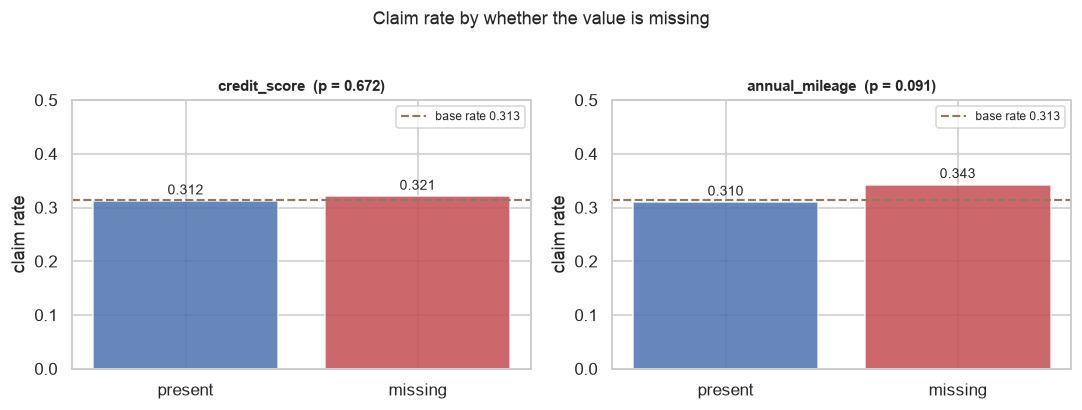

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, col in zip(axes, cfg.COLUMNS_WITH_MISSING):
    m = train[col].isna()
    rates = [train.loc[~m, cfg.TARGET].mean(), train.loc[m, cfg.TARGET].mean()]
    ax.bar(["present", "missing"], rates, color=["#4C72B0", "#C44E52"], alpha=0.85)
    ax.axhline(train[cfg.TARGET].mean(), color="#937860", ls="--", lw=1.4,
               label=f"base rate {train[cfg.TARGET].mean():.3f}")
    p = missingness.loc[missingness["column"] == col, "p_value"].iloc[0]
    ax.set_title(f"{col}  (p = {p:.3f})", fontsize=10)
    ax.set_ylabel("claim rate"); ax.set_ylim(0, 0.5); ax.legend(fontsize=8)
    for i, r in enumerate(rates):
        ax.text(i, r + 0.012, f"{r:.3f}", ha="center", fontsize=9)
fig.suptitle("Claim rate by whether the value is missing", y=1.03, fontsize=12)
fig.tight_layout()
save_fig(fig, "missingness_vs_outcome")
plt.show()

## 2. D3 — what does the leakage actually cost?

The reference computes each median over all 10,000 rows and then fills the training rows
with it. Test rows therefore influence the values used during training. The fix is one
line of discipline: fit on train, apply everywhere.

The interesting question is not whether this is wrong in principle — it is — but how much
it moves the number. That is measurable, so we measure it rather than asserting it.

In [5]:
honest = MedianImputer().fit(train)
leaky = MedianImputer().fit(df)   # what the reference does

pd.DataFrame({
    "train_only (honest)": honest.medians_,
    "full_data (leaky)": leaky.medians_,
}).assign(difference=lambda d: d["full_data (leaky)"] - d["train_only (honest)"])

,train_only (honest),full_data (leaky),difference
credit_score,0.523982,0.525033,0.001051
annual_mileage,12000.000000,12000.000000,0.000000


The medians differ by 0.001 on `credit_score` and not at all on `annual_mileage`, which
is recorded in round thousands and so has a median of exactly 12,000 either way.

Tiny. But "tiny" is a measurement, not a prior. Here is what it costs downstream, fitting
the same single-feature model under each imputation and scoring on validation.

In [6]:
rows = []
for col in cfg.COLUMNS_WITH_MISSING:
    for label, imputer in [("honest (train-fitted)", honest), ("leaky (full-data)", leaky)]:
        Xtr = sm.add_constant(build_design(imputer.transform(train), [col], "dummy"))
        Xva = sm.add_constant(build_design(imputer.transform(val), [col], "dummy"),
                              has_constant="add")
        model = sm.Logit(train[cfg.TARGET], Xtr).fit(disp=0)
        pred = (model.predict(Xva) >= 0.5).astype(int)
        rows.append({"feature": col, "imputation": label,
                     "val_accuracy": (pred == val[cfg.TARGET]).mean()})

leak = pd.DataFrame(rows).pivot(index="feature", columns="imputation", values="val_accuracy")
leak["delta"] = leak["leaky (full-data)"] - leak["honest (train-fitted)"]
leak["rows_flipped"] = (leak["delta"].abs() * len(val)).round().astype(int)
leak.round(6)

imputation,honest (train-fitted),leaky (full-data),delta,rows_flipped
feature,,,,
annual_mileage,0.692,0.692000,0.000000,0
credit_score,0.712,0.711333,-0.000667,1


### Verdict on D3

The leak changes **one prediction out of 1,500** on `credit_score`, and none at all on
`annual_mileage`.

That is the honest finding, and it should be reported as such rather than dressed up. On
this dataset the leakage is immaterial: 10,000 rows and a stable median make it so. The
reason to fix it anyway is that *you cannot know it is immaterial without measuring it*,
and the same defect on a smaller sample, a skewed column, or a group-wise imputation
would not be so forgiving. The discipline is cheap; discovering you needed it after
publishing is not.

Both the leaky and honest numbers are recorded, so the README can quantify the claim
instead of gesturing at best practice.

## 3. D4 — encoding by meaning, not by dtype

The reference's feature loop hands each column to a formula interface and lets pandas
dtypes decide what happens:

- `driving_experience` is a string, so it is silently expanded into **3 dummy variables**
- `age` is an integer, so it enters as **1 linear term**
- `postal_code` is an integer, so a single slope is fitted across 10238 … 92101

Those three models are then compared on raw accuracy, with no account taken of the fact
that one has three extra degrees of freedom and another is doing arithmetic on labels.

In [7]:
# Confirm the reference's behaviour on the current stack (statsmodels 0.15 replaced
# patsy with formulaic, so this needed rechecking rather than assuming).
from statsmodels.formula.api import logit

ref = honest.transform(train)
for f in ["driving_experience", "age", "postal_code"]:
    m = logit(f"outcome ~ {f}", data=ref).fit(disp=0)
    print(f"{f:20s} {len(m.params) - 1} parameter(s): {[t for t in m.params.index if t != 'Intercept']}")

driving_experience   3 parameter(s): ['driving_experience[T.10-19y]', 'driving_experience[T.20-29y]', 'driving_experience[T.30y+]']
age                  1 parameter(s): ['age']


postal_code          1 parameter(s): ['postal_code']


In [8]:
# Our encoding: the choice is explicit and applied uniformly to every feature.
counts = pd.DataFrame({
    "linear": [n_parameters(ref, f, "linear") for f in cfg.FEATURES],
    "dummy": [n_parameters(ref, f, "dummy") for f in cfg.FEATURES],
}, index=cfg.FEATURES)
counts["kind"] = [
    "ordinal" if f in cfg.ORDINAL_LEVELS else
    "nominal" if f in cfg.NOMINAL else
    "binary" if f in cfg.BINARY else
    "count" if f in cfg.COUNTS else "continuous"
    for f in cfg.FEATURES
]
counts[["kind", "linear", "dummy"]]

,kind,linear,dummy
age,ordinal,1,3
gender,nominal,1,1
driving_experience,ordinal,1,3
education,ordinal,1,2
income,ordinal,1,3
credit_score,continuous,1,1
vehicle_ownership,binary,1,1
vehicle_year,nominal,1,1
married,binary,1,1
children,binary,1,1


Under either scheme, applied consistently, `age` and `driving_experience` contribute the
same number of parameters — so Session 3 compares them on equal terms and reports both
schemes side by side.

Two details in that table are worth reading carefully.

`postal_code` shows 3 parameters under **both** schemes. It is nominal, so it is never
encoded linearly; the meaningless slope across postal code integers is not an option the
pipeline can express. That is the second face of D4, closed off in code.

The two schemes are a genuine trade-off, not a right answer and a wrong one. Linear
encoding costs one parameter but assumes the effect is monotone and evenly spaced across
levels. Dummy encoding assumes nothing about shape, and pays (k − 1) parameters for it.
Session 3 runs both and reports AIC, which prices the extra parameters explicitly.

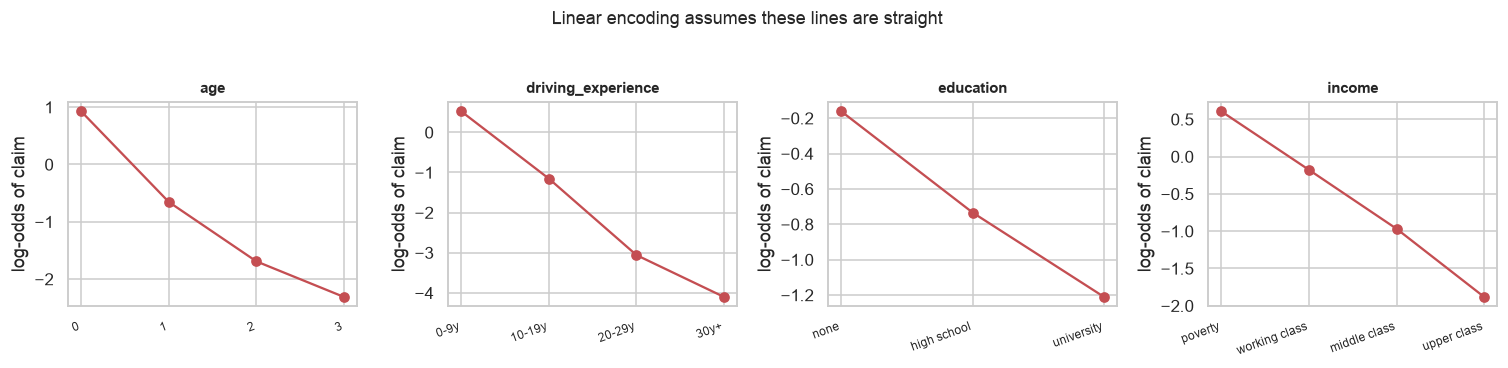

In [9]:
# Is the monotone-and-evenly-spaced assumption reasonable? Log-odds by ordinal level.
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for ax, (feat, levels) in zip(axes, cfg.ORDINAL_LEVELS.items()):
    g = train.groupby(feat, observed=True)[cfg.TARGET].mean().reindex(levels)
    logodds = np.log(g / (1 - g))
    ax.plot(range(len(levels)), logodds, "o-", color="#C44E52")
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([str(l) for l in levels], rotation=20, ha="right", fontsize=8)
    ax.set_title(feat, fontsize=10)
    ax.set_ylabel("log-odds of claim")
fig.suptitle("Linear encoding assumes these lines are straight", y=1.04, fontsize=12)
fig.tight_layout()
save_fig(fig, "ordinal_log_odds")
plt.show()

Straight lines would vindicate the linear encoding. `income` and `education` are close to
straight. `age` and `driving_experience` bend, which suggests dummy encoding will fit them
better — and that the extra parameters may be earning their keep rather than merely
inflating accuracy. Session 3 settles that with AIC rather than by eye.

## 4. What carries into Session 3

- **Missingness is uninformative** (D6 closed). Median imputation, no indicator variable.
- **Imputation is fitted on train** (D3 closed). The leak was worth one flipped prediction
  in 1,500; recorded so the README can state the size rather than the principle.
- **Encoding is explicit and uniform** (D4 closed). Both schemes available, parameter
  counts reported alongside every accuracy.
- The ordinal log-odds are visibly curved for `age` and `driving_experience`, so the two
  schemes are expected to disagree. That disagreement is a result, not a nuisance.

In [10]:
cfg.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
missingness.to_csv(cfg.DATA_PROCESSED / "results_missingness.csv", index=False)
mar.to_csv(cfg.DATA_PROCESSED / "results_missingness_mar.csv", index=False)
leak.to_csv(cfg.DATA_PROCESSED / "results_imputation_leak.csv")
counts[["kind", "linear", "dummy"]].to_csv(cfg.DATA_PROCESSED / "results_encoding_parameters.csv")
print("wrote 4 result tables to data/processed/")

wrote 4 result tables to data/processed/
